In [2]:
import json
import chess
from collections import Counter, defaultdict
import matplotlib.pyplot as plt

In [3]:
with open("../dataset_with_turn.json", "r") as f:
    data = json.load(f)

X = data["X"]
y_from = data["y_from"]
y_to = data["y_to"]
turns = data["turn"]

print("Dataset Loaded ✅")

Dataset Loaded ✅


In [4]:
print("Total samples:", len(X))
print("Input vector size:", len(X[0]))
print("y_from length:", len(y_from))
print("y_to length:", len(y_to))
print("turns length:", len(turns))

assert len(X) == len(y_from) == len(y_to) == len(turns)
print("Alignment check passed ✅")

Total samples: 236189
Input vector size: 64
y_from length: 236189
y_to length: 236189
turns length: 236189
Alignment check passed ✅


In [5]:
all_values = [v for board in X for v in board]

print("Min value:", min(all_values))
print("Max value:", max(all_values))

Min value: -6
Max value: 6


In [6]:
from_counter = Counter(y_from)
to_counter = Counter(y_to)

print("Top FROM squares:")
for sq, c in from_counter.most_common(10):
    print(chess.square_name(sq), c)

print("\nTop TO squares:")
for sq, c in to_counter.most_common(10):
    print(chess.square_name(sq), c)

Top FROM squares:
e7 8428
e2 8298
d7 7527
f1 7213
f8 7128
d2 7090
d1 6363
e5 6177
g8 6110
g1 6031

Top TO squares:
e5 12751
d4 11890
c3 8950
f3 8860
f6 8696
c6 8342
d6 7265
f4 7026
e3 5751
e7 5742


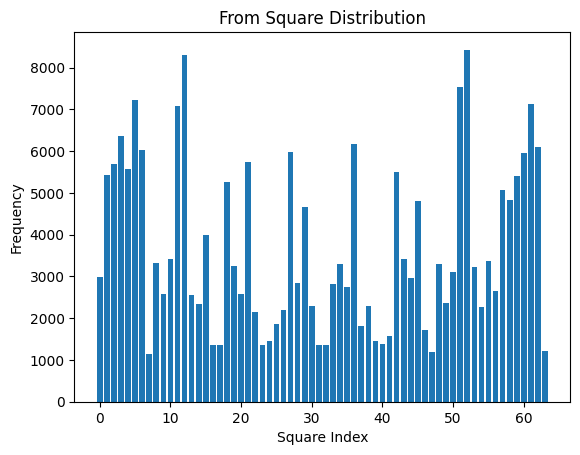

In [7]:
plt.figure()
plt.bar(from_counter.keys(), from_counter.values())
plt.title("From Square Distribution")
plt.xlabel("Square Index")
plt.ylabel("Frequency")
plt.show()

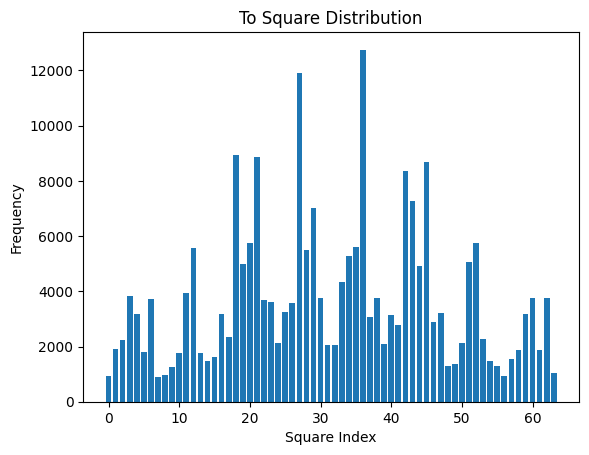

In [8]:
plt.figure()
plt.bar(to_counter.keys(), to_counter.values())
plt.title("To Square Distribution")
plt.xlabel("Square Index")
plt.ylabel("Frequency")
plt.show()

In [9]:
def board_to_vector(board):
    piece_map = {
        chess.PAWN: 1,
        chess.KNIGHT: 2,
        chess.BISHOP: 3,
        chess.ROOK: 4,
        chess.QUEEN: 5,
        chess.KING: 6
    }

    vec = []
    for sq in chess.SQUARES:
        piece = board.piece_at(sq)
        if piece is None:
            vec.append(0)
        else:
            val = piece_map[piece.piece_type]
            vec.append(val if piece.color else -val)
    return vec

initial_vector = board_to_vector(chess.Board())

opening_moves = Counter()

for i in range(len(X)):
    if X[i] == initial_vector:
        opening_moves[y_from[i]] += 1

print("Opening moves:")
for sq, c in opening_moves.most_common(10):
    print(chess.square_name(sq), c)

Opening moves:
d2 3771
g1 275
e2 152
b1 6


In [10]:
white_moves = sum(1 for t in turns if t == 1)
black_moves = sum(1 for t in turns if t == 0)

print("White moves:", white_moves)
print("Black moves:", black_moves)

White moves: 123189
Black moves: 113000


In [11]:
print("Unique FROM squares:", len(from_counter))
print("Unique TO squares:", len(to_counter))

Unique FROM squares: 64
Unique TO squares: 64


In [12]:
most = max(from_counter.values())
least = min(from_counter.values())

print("Most frequent:", most)
print("Least frequent:", least)
print("Imbalance ratio:", most / least)

Most frequent: 8428
Least frequent: 1142
Imbalance ratio: 7.380035026269702


In [13]:
position_count = defaultdict(int)

for board in X:
    position_count[tuple(board)] += 1

duplicates = sum(1 for v in position_count.values() if v > 1)

print("Repeated positions:", duplicates)

Repeated positions: 5660


In [14]:
piece_usage = Counter()

for board in X:
    for val in board:
        if val != 0:
            piece_usage[val] += 1

print("Piece usage:")
for piece, count in piece_usage.items():
    print(piece, count)

Piece usage:
4 383191
2 246972
3 266374
5 159696
6 236189
1 1505744
-1 1468919
-4 379390
-2 243679
-3 271058
-5 160304
-6 236189


In [15]:
for i in range(5):
    print("Move:", chess.square_name(y_from[i]), "→", chess.square_name(y_to[i]))
    print("Turn:", "White" if turns[i] == 1 else "Black")
    print("Board (first 10 values):", X[i][:10])
    print("-" * 40)

Move: d7 → d6
Turn: Black
Board (first 10 values): [4, 2, 3, 5, 6, 3, 0, 4, 1, 1]
----------------------------------------
Move: g8 → f6
Turn: Black
Board (first 10 values): [4, 2, 3, 5, 6, 3, 0, 4, 1, 1]
----------------------------------------
Move: e7 → e5
Turn: Black
Board (first 10 values): [4, 2, 3, 5, 6, 3, 0, 4, 1, 1]
----------------------------------------
Move: c8 → e6
Turn: Black
Board (first 10 values): [4, 0, 3, 5, 6, 3, 0, 4, 1, 1]
----------------------------------------
Move: f8 → e7
Turn: Black
Board (first 10 values): [4, 0, 3, 5, 6, 3, 0, 4, 1, 1]
----------------------------------------
